In [84]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
raw_df = pd.read_csv("bim_ai_civil_engineering_dataset.csv")
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
raw_df.head()

,Project_ID,Project_Type,Location,Start_Date,End_Date,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,Schedule_Deviation,Vibration_Level,Crack_Width,Load_Bearing_Capacity,Temperature,Humidity,Weather_Condition,Air_Quality_Index,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage,Risk_Level
0,PJT_1,Tunnel,Houston,2020-01-01,2021-09-26,12260784,15054504.05,2793720.05,699,813.91,114.91,1.53,2.81,471.20,18.54,49.88,Snowy,210,25202.99,244.84,6602,76.30,8,6.19,52.99,0,95.01,High
1,PJT_2,Dam,Houston,2020-01-02,2020-12-06,2369277,3507053.96,1137776.96,269,384.12,115.12,0.69,3.70,355.16,23.32,58.64,Snowy,195,49066.17,263.12,7121,63.53,5,2.13,50.89,0,25.29,Low
2,PJT_3,Building,Houston,2020-01-03,2021-12-05,23299783,21692126.70,-1607656.30,899,1081.78,182.78,0.95,3.31,236.49,42.96,36.17,Cloudy,127,48192.55,608.99,9956,47.10,2,3.11,93.91,0,97.48,Medium
3,PJT_4,Dam,Houston,2020-01-04,2022-04-12,24499306,29469660.50,4970354.50,809,974.57,165.57,0.87,1.78,360.29,22.42,72.05,Cloudy,71,19811.15,673.57,3725,86.85,5,4.07,90.45,1,95.10,High
4,PJT_5,Dam,Seattle,2020-01-05,2022-02-12,1749971,2329338.04,579367.04,354,347.99,-6.01,1.97,4.04,204.79,15.91,57.24,Cloudy,113,44866.57,765.48,4368,61.83,6,2.76,78.39,0,43.62,Low


In [3]:
raw_df.drop(columns=['Project_ID','Start_Date','End_Date','Location','Safety_Risk_Score'],inplace=True)
raw_df.head()

,Project_Type,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,Schedule_Deviation,Vibration_Level,Crack_Width,Load_Bearing_Capacity,Temperature,Humidity,Weather_Condition,Air_Quality_Index,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage,Risk_Level
0,Tunnel,12260784,15054504.05,2793720.05,699,813.91,114.91,1.53,2.81,471.20,18.54,49.88,Snowy,210,25202.99,244.84,6602,76.30,8,52.99,0,95.01,High
1,Dam,2369277,3507053.96,1137776.96,269,384.12,115.12,0.69,3.70,355.16,23.32,58.64,Snowy,195,49066.17,263.12,7121,63.53,5,50.89,0,25.29,Low
2,Building,23299783,21692126.70,-1607656.30,899,1081.78,182.78,0.95,3.31,236.49,42.96,36.17,Cloudy,127,48192.55,608.99,9956,47.10,2,93.91,0,97.48,Medium
3,Dam,24499306,29469660.50,4970354.50,809,974.57,165.57,0.87,1.78,360.29,22.42,72.05,Cloudy,71,19811.15,673.57,3725,86.85,5,90.45,1,95.10,High
4,Dam,1749971,2329338.04,579367.04,354,347.99,-6.01,1.97,4.04,204.79,15.91,57.24,Cloudy,113,44866.57,765.48,4368,61.83,6,78.39,0,43.62,Low


We Need to keep completion percentage because for example, high vibration at 15% completion (just started) may be Low risk, but at 85% completion it could be High risk.

In [4]:
RISK_MAPPING = {'Low':0,'Medium':1,'High':2}
raw_df["target_numeric"] = raw_df['Risk_Level'].map(RISK_MAPPING)

In [5]:
raw_df.head()

,Project_Type,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,Schedule_Deviation,Vibration_Level,Crack_Width,Load_Bearing_Capacity,Temperature,Humidity,Weather_Condition,Air_Quality_Index,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage,Risk_Level,target_numeric
0,Tunnel,12260784,15054504.05,2793720.05,699,813.91,114.91,1.53,2.81,471.20,18.54,49.88,Snowy,210,25202.99,244.84,6602,76.30,8,52.99,0,95.01,High,2
1,Dam,2369277,3507053.96,1137776.96,269,384.12,115.12,0.69,3.70,355.16,23.32,58.64,Snowy,195,49066.17,263.12,7121,63.53,5,50.89,0,25.29,Low,0
2,Building,23299783,21692126.70,-1607656.30,899,1081.78,182.78,0.95,3.31,236.49,42.96,36.17,Cloudy,127,48192.55,608.99,9956,47.10,2,93.91,0,97.48,Medium,1
3,Dam,24499306,29469660.50,4970354.50,809,974.57,165.57,0.87,1.78,360.29,22.42,72.05,Cloudy,71,19811.15,673.57,3725,86.85,5,90.45,1,95.10,High,2
4,Dam,1749971,2329338.04,579367.04,354,347.99,-6.01,1.97,4.04,204.79,15.91,57.24,Cloudy,113,44866.57,765.48,4368,61.83,6,78.39,0,43.62,Low,0


In [6]:
input_cols = ['Project_Type', 'Planned_Cost', 'Planned_Duration', 'Vibration_Level', 'Crack_Width', 'Load_Bearing_Capacity', 'Temperature', 'Humidity', 'Weather_Condition', 'Air_Quality_Index', 'Energy_Consumption', 'Material_Usage', 'Labor_Hours', 'Equipment_Utilization', 'Accident_Count', 'Image_Analysis_Score', 'Anomaly_Detected', 'Completion_Percentage']
target_col = 'Risk_Level'

In [7]:
print(raw_df[input_cols].shape)
raw_df[input_cols].head()

(1000, 18)


,Project_Type,Planned_Cost,Planned_Duration,Vibration_Level,Crack_Width,Load_Bearing_Capacity,Temperature,Humidity,Weather_Condition,Air_Quality_Index,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage
0,Tunnel,12260784,699,1.53,2.81,471.20,18.54,49.88,Snowy,210,25202.99,244.84,6602,76.30,8,52.99,0,95.01
1,Dam,2369277,269,0.69,3.70,355.16,23.32,58.64,Snowy,195,49066.17,263.12,7121,63.53,5,50.89,0,25.29
2,Building,23299783,899,0.95,3.31,236.49,42.96,36.17,Cloudy,127,48192.55,608.99,9956,47.10,2,93.91,0,97.48
3,Dam,24499306,809,0.87,1.78,360.29,22.42,72.05,Cloudy,71,19811.15,673.57,3725,86.85,5,90.45,1,95.10
4,Dam,1749971,354,1.97,4.04,204.79,15.91,57.24,Cloudy,113,44866.57,765.48,4368,61.83,6,78.39,0,43.62


# Data Set Saving :

In [8]:
raw_df.to_parquet('main_df.parquet', index=True)

In [9]:
raw_df['Anomaly_Detected'].value_counts()

Anomaly_Detected
0    803
1    197
Name: count, dtype: int64

In [10]:
#raw_df.head()

In [11]:
numerical_cols = raw_df[input_cols].select_dtypes(include='number').columns.to_list()
print(f"numerical_cols : {numerical_cols}")
categorical_cols = raw_df[input_cols].select_dtypes(include='object').columns.to_list()
print(f"Categorical cols : {categorical_cols}")

numerical_cols : ['Planned_Cost', 'Planned_Duration', 'Vibration_Level', 'Crack_Width', 'Load_Bearing_Capacity', 'Temperature', 'Humidity', 'Air_Quality_Index', 'Energy_Consumption', 'Material_Usage', 'Labor_Hours', 'Equipment_Utilization', 'Accident_Count', 'Image_Analysis_Score', 'Anomaly_Detected', 'Completion_Percentage']
Categorical cols : ['Project_Type', 'Weather_Condition']


In [12]:
raw_df['Project_Type'].value_counts()

Project_Type
Bridge      210
Tunnel      206
Dam         204
Building    190
Road        190
Name: count, dtype: int64

In [13]:
raw_df['Weather_Condition'].value_counts()

Weather_Condition
Rainy     216
Snowy     206
Cloudy    201
Stormy    194
Sunny     183
Name: count, dtype: int64

# Data Splitting :

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(raw_df[input_cols].copy(), raw_df[target_col].copy(), test_size=0.15, random_state=42)

In [15]:
print(f"x_train.shape : {x_train.shape}")
print(f"y_train.shape : {y_train.shape}")

x_train.shape : (850, 18)
y_train.shape : (850,)


In [16]:
print(f"x_test.shape : {x_test.shape}")
print(f"y_test.shape : {y_test.shape}")

x_test.shape : (150, 18)
y_test.shape : (150,)


# Encoding of Categorical Data :

In [17]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

In [18]:
encoder.fit(x_train[categorical_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [19]:
encoded_cols = encoder.get_feature_names_out()
print(encoded_cols)

['Project_Type_Bridge' 'Project_Type_Building' 'Project_Type_Dam'
 'Project_Type_Road' 'Project_Type_Tunnel' 'Weather_Condition_Cloudy'
 'Weather_Condition_Rainy' 'Weather_Condition_Snowy'
 'Weather_Condition_Stormy' 'Weather_Condition_Sunny']


In [20]:
x_train[encoded_cols] = encoder.transform(x_train[categorical_cols])
x_test[encoded_cols] = encoder.transform(x_test[categorical_cols])
x_train.drop(columns=['Project_Type','Weather_Condition'],inplace=True)
x_test.drop(columns=['Project_Type','Weather_Condition'],inplace=True)
x_train.shape

(850, 26)

For Target column :

In [21]:
target_count = y_train.value_counts()

In [22]:
RISK_MAPPING = {'Low':0,'Medium':1,'High':2}
y_train = y_train.map(RISK_MAPPING)
y_test = y_test.map(RISK_MAPPING)
#y_train

# Exploratory Data Analysis :

In [23]:
corr_matrix = x_train[numerical_cols].corr()

Text(0.5, 1.0, 'Cor-relation Matrix')

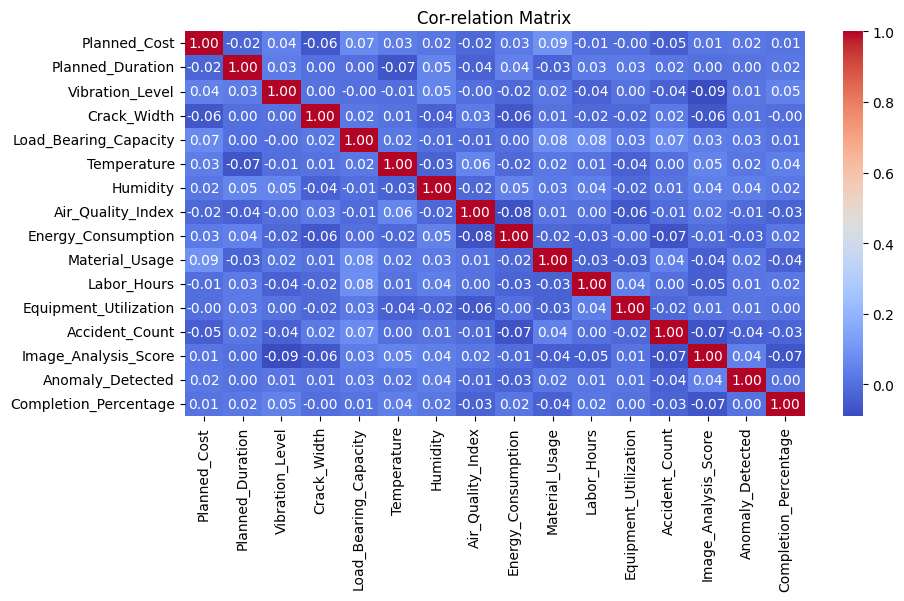

In [24]:
plt.figure(figsize=(10,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title("Cor-relation Matrix")


Text(0.5, 1.0, 'Target Class Distribution')

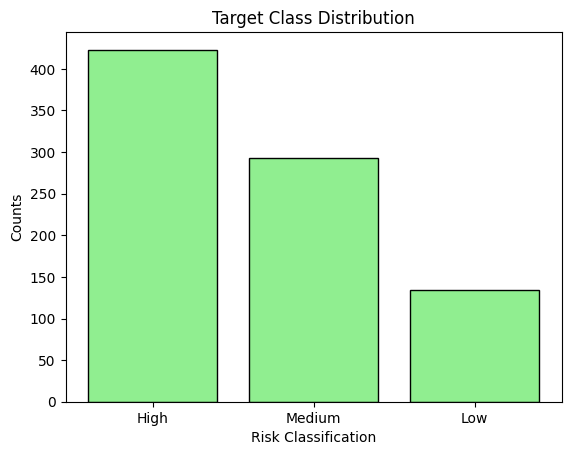

In [25]:
plt.bar(target_count.index,target_count.values,edgecolor='black',facecolor='lightgreen')
plt.xlabel("Risk Classification")
plt.ylabel("Counts")
plt.title("Target Class Distribution")

# Scaling and Imputation :

Since there are no null values and Duplicate values are found so, There is no need of imputation.

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [27]:
scaler.fit(x_train[numerical_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [28]:
x_train[numerical_cols] = scaler.transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

In [29]:
#x_train[numerical_cols].describe()
x_test[numerical_cols].describe()

,Planned_Cost,Planned_Duration,Vibration_Level,Crack_Width,Load_Bearing_Capacity,Temperature,Humidity,Air_Quality_Index,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage
count,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00
mean,0.00,-0.06,-0.01,0.10,0.02,-0.18,0.14,-0.09,-0.02,0.02,-0.06,0.07,0.12,-0.11,-0.03,-0.11
std,1.06,0.98,1.04,1.04,1.07,0.96,1.05,1.06,0.98,1.02,0.97,0.93,1.02,1.06,0.98,0.94
min,-1.76,-1.72,-1.70,-1.64,-1.68,-1.79,-1.70,-1.73,-1.68,-1.68,-1.63,-1.59,-1.58,-1.74,-0.50,-1.75
25%,-0.99,-0.88,-0.91,-0.85,-0.98,-0.90,-0.79,-1.09,-0.80,-0.88,-0.94,-0.76,-0.53,-1.07,-0.50,-0.96
50%,0.07,-0.14,0.04,0.03,0.08,-0.33,0.20,-0.05,-0.04,0.04,0.04,0.06,0.17,-0.21,-0.50,-0.03
75%,1.07,0.75,0.92,1.07,1.02,0.61,1.03,0.86,0.71,0.91,0.81,0.86,0.87,0.82,-0.50,0.61
max,1.63,1.68,1.73,1.80,1.78,1.74,1.73,1.72,1.72,1.74,1.74,1.74,1.56,1.72,2.01,1.70


So scaling is Done.

# Model training :

In [30]:
from sklearn.metrics import accuracy_score,precision_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay,f1_score

In [31]:
from sklearn.naive_bayes import GaussianNB
GNB_model = GaussianNB(priors=None,var_smoothing=1e-9)

In [32]:
GNB_model.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [33]:
GNB_model.classes_

array([0, 1, 2])

In [34]:
GNB_train_predictions = GNB_model.predict(x_train)
GNB_test_predictions = GNB_model.predict(x_test)

In [35]:
GNB_model.score(x_train,y_train)

0.28823529411764703

In [36]:
GNB_model.score(x_test,y_test)

0.29333333333333333

In [37]:
GNB_train_precision_score = precision_score(y_train,GNB_train_predictions, average='weighted')
print(f"GNB_train_precision_score : {GNB_train_precision_score}")
GNB_test_precision_score = precision_score(y_test,GNB_test_predictions, average='weighted')
print(f"GNB_test_precision_score : {GNB_test_precision_score}")

GNB_train_precision_score : 0.5321217303901937
GNB_test_precision_score : 0.4555838899008298


In [38]:
GNB_f1_score = f1_score(GNB_test_predictions,y_test,average='weighted') 
print(f"GNB_f1_score : {GNB_f1_score}")

GNB_f1_score : 0.323235499650594


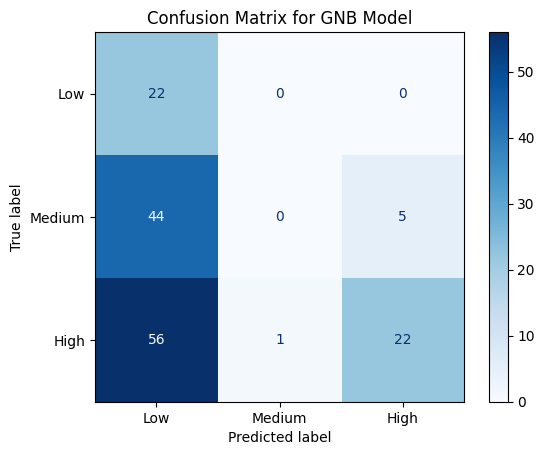

In [39]:
GNB_conf_matrix = confusion_matrix(y_test,GNB_test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=GNB_conf_matrix, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for GNB Model")
plt.show()

LogisticRegressionCV model:

In [40]:
from sklearn.linear_model import LogisticRegressionCV
linear_model = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty='l2',
    solver='lbfgs',
    scoring='roc_auc_ovo',
    class_weight='balanced',
    max_iter=2000,
    n_jobs=-1,
)

In [41]:
linear_model.fit(x_train,y_train)

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'roc_auc_ovo'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass se

In [42]:
linear_model.score(x_train,y_train)

np.float64(0.654603387985078)

In [43]:
linear_model.score(x_test,y_test)

np.float64(0.5093782046765772)

In [44]:
linear_train_predictions = linear_model.predict(x_train)
linear_test_predictions = linear_model.predict(x_test)
linear_train_precision_score = precision_score(y_train,linear_train_predictions,average='weighted')
print(f"linear_train_precision_score : {linear_train_precision_score}")
linear_test_precision_score = precision_score(y_test,linear_test_predictions,average='weighted')
print(f"linear_test_precision_score : {linear_test_precision_score}")

linear_train_precision_score : 0.5144624479799776
linear_test_precision_score : 0.46589743589743593


In [45]:
linear_f1_score = f1_score(linear_test_predictions,y_test,average='weighted') 
print(f"linear_f1_score : {linear_f1_score}")

linear_f1_score : 0.3249398556535686


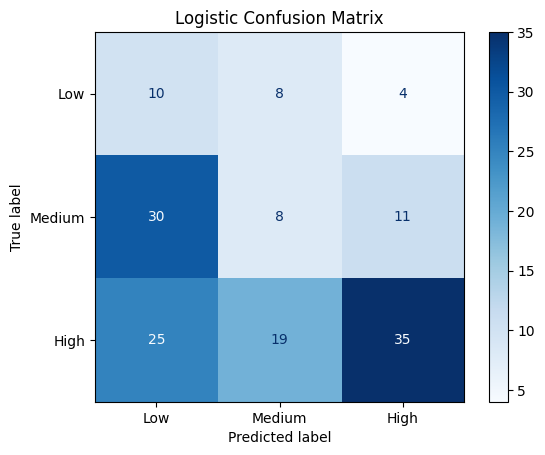

In [46]:
linear_conf_matrix = confusion_matrix(y_test,linear_test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=linear_conf_matrix, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title("Logistic Confusion Matrix")
plt.show()

Supporting Vector Machine :

In [47]:
from sklearn.svm import SVC
svc_model = SVC(kernel='rbf', C=1.0, gamma='auto',random_state=42)

In [48]:
svc_model.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [49]:
svc_model.score(x_train,y_train)

0.5835294117647059

In [50]:
svc_model.score(x_test,y_test)

0.49333333333333335

In [51]:
svc_train_predictions = svc_model.predict(x_train)
svc_test_predictions = svc_model.predict(x_test)
svc_train_precision_score = precision_score(y_train,svc_train_predictions,average='weighted')
print(f"svc_train_precision_score : {svc_train_precision_score}")
svc_test_precision_score = precision_score(y_test,svc_test_predictions,average='weighted')
print(f"svc_test_precision_score : {svc_test_precision_score}")

svc_train_precision_score : 0.5479614353474944
svc_test_precision_score : 0.3483286543140558


In [52]:
svc_f1_score = f1_score(svc_test_predictions,y_test,average='weighted') 
print(f"svc_f1_score : {svc_f1_score}")

svc_f1_score : 0.6088191955396257


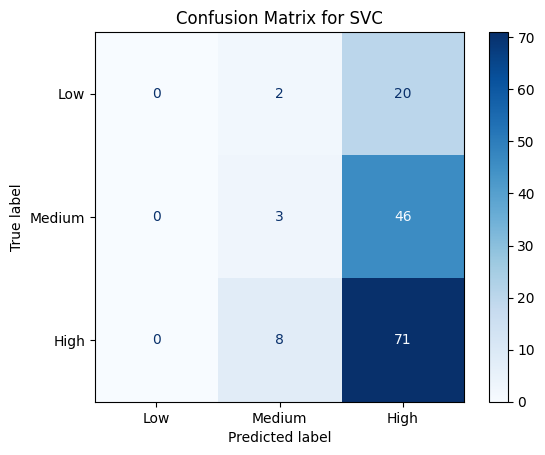

In [53]:
svc_conf_matrix = confusion_matrix(y_test,svc_test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=svc_conf_matrix, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for SVC")
plt.show()

RandomForestClassifier :

In [54]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42,n_jobs=-1)

In [55]:
rf_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [56]:
rf_model.score(x_train,y_train)

1.0

In [57]:
rf_model.score(x_test,y_test)

0.44666666666666666

Hyperparameter tuning for random forest using GridsearchCV.

In [58]:
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight' : ['balanced']
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,              
    scoring='f1',
    n_jobs=-1          
)

grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [59]:
grid_rf_model = grid.best_estimator_

In [60]:
grid_rf_model.score(x_train,y_train)

1.0

In [61]:
grid_rf_model.score(x_test,y_test)

0.49333333333333335

In [62]:
grid_rf_train_predictions = grid_rf_model.predict(x_train)
grid_rf_test_predictions = grid_rf_model.predict(x_test)
grid_rf_train_precision = precision_score(grid_rf_train_predictions,y_train,average='weighted')
grid_rf_test_precision = precision_score(grid_rf_test_predictions,y_test,average='weighted')
print(f"grid_rf_train_precision : {grid_rf_train_precision}")
print(f"grid_rf_test_precision : {grid_rf_test_precision}")

grid_rf_train_precision : 1.0
grid_rf_test_precision : 0.621549987083441


In [63]:
grid_rf_f1_score = f1_score(y_test,grid_rf_test_predictions,average='weighted') 
print(f"grid_rf_f1_score : {grid_rf_f1_score}")

grid_rf_f1_score : 0.44087874028432195


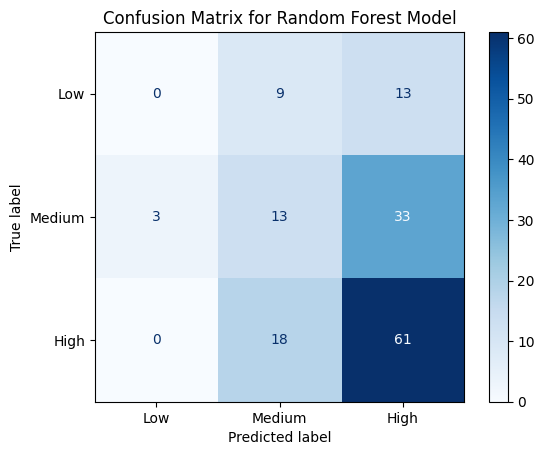

In [64]:
rf_conf_matrix = confusion_matrix(y_test,grid_rf_test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_conf_matrix, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Random Forest Model")
plt.show()

XGBoost Model :

In [65]:
from xgboost import XGBClassifier

In [66]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    use_label_encoder=False,
    eval_metric='mlogloss',  # for multiclass
    random_state=42
)

xgb_model.fit(x_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [67]:
xgb_model.score(x_train,y_train)

0.9411764705882353

In [68]:
xgb_model.score(x_test,y_test)

0.5133333333333333

In [69]:
xgb_train_predictions = xgb_model.predict(x_train)
xgb_test_predictions = xgb_model.predict(x_test)
xgb_train_precision = precision_score(y_train,xgb_train_predictions,average='weighted')
xgb_test_precision = precision_score(y_test,xgb_test_predictions,average='weighted')
print(f"xgb_train_precision : {xgb_train_precision}")
print(f"xgb_test_precision : {xgb_test_precision}")

xgb_train_precision : 0.9437279317486497
xgb_test_precision : 0.4723662444328764


In [70]:
xgb_f1_score = f1_score(y_test,xgb_test_predictions,average='weighted') 
print(f"xgb_f1_score : {xgb_f1_score}")

xgb_f1_score : 0.4620730254350736


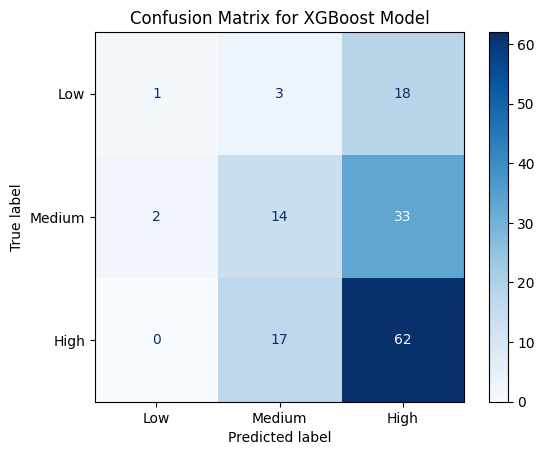

In [71]:
xgb_conf_matrix = confusion_matrix(y_test,xgb_test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_conf_matrix, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for XGBoost Model")
plt.show()

In [72]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score
import numpy as np

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 300),        # don't need 1000
        "max_depth":         trial.suggest_int("max_depth", 3, 6),               # cap at 6, not 10
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 3, 10),       # was 1-10, raise floor
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.01, 10.0, log=True),  # meaningful L1
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),  # meaningful L2
        "random_state": 42,
        "eval_metric": "mlogloss",
    }

    model = xgb.XGBClassifier(**params)

    # Use cross_val_score for reliable estimate
    scores = cross_val_score(
        model, x_train, y_train,
        cv=5,
        scoring="f1_weighted",   # good for imbalanced multiclass
        n_jobs=-1
    )
    return scores.mean()


# Create and run the study
study = optuna.create_study(direction="maximize")  # maximizing f1
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best trial:", study.best_trial.number)
print("Best F1:", study.best_value)
print("Best params:", study.best_params)

[I 2026-04-04 17:59:04,066] A new study created in memory with name: no-name-7cb94031-bcd2-4c1c-97f8-9bdcf80128b9


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-04 17:59:04,882] Trial 0 finished with value: 0.39776193333102766 and parameters: {'n_estimators': 203, 'max_depth': 3, 'learning_rate': 0.21891399943276565, 'subsample': 0.7604622520674257, 'colsample_bytree': 0.9339214364944131, 'min_child_weight': 5, 'reg_alpha': 0.01125099901497224, 'reg_lambda': 1.0304431422247717}. Best is trial 0 with value: 0.39776193333102766.
[I 2026-04-04 17:59:06,182] Trial 1 finished with value: 0.407250683490162 and parameters: {'n_estimators': 165, 'max_depth': 6, 'learning_rate': 0.09097602580252263, 'subsample': 0.7746551740848017, 'colsample_bytree': 0.9596309999875824, 'min_child_weight': 3, 'reg_alpha': 0.08860418153168344, 'reg_lambda': 1.52593555957381}. Best is trial 1 with value: 0.407250683490162.
[I 2026-04-04 17:59:06,930] Trial 2 finished with value: 0.3370627168331774 and parameters: {'n_estimators': 51, 'max_depth': 6, 'learning_rate': 0.01345187563698977, 'subsample': 0.6919682744367619, 'colsample_bytree': 0.7262449839586322, 

In [73]:
optuna_model = XGBClassifier(**study.best_params)
optuna_model.fit(x_train,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8556089668081978
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegress

In [74]:
optuna_model.score(x_train,y_train)

0.9952941176470588

In [75]:
optuna_model.score(x_test,y_test)

0.38666666666666666

In [76]:
optuna_train_predictions = optuna_model.predict(x_train)
optuna_test_predictions = optuna_model.predict(x_test)
optuna_train_precision = precision_score(y_train,optuna_train_predictions,average='weighted')
optuna_test_precision = precision_score(y_test,optuna_test_predictions,average='weighted')
print(f"optuna_train_precision : {optuna_train_precision}")
print(f"optuna_test_precision : {optuna_test_precision}")

optuna_train_precision : 0.9953211424549879
optuna_test_precision : 0.3434814814814815


In [77]:
optuna_f1_score = f1_score(y_test,optuna_test_predictions,average='weighted') 
print(f"optuna_f1_score : {optuna_f1_score}")

optuna_f1_score : 0.3537438678823044


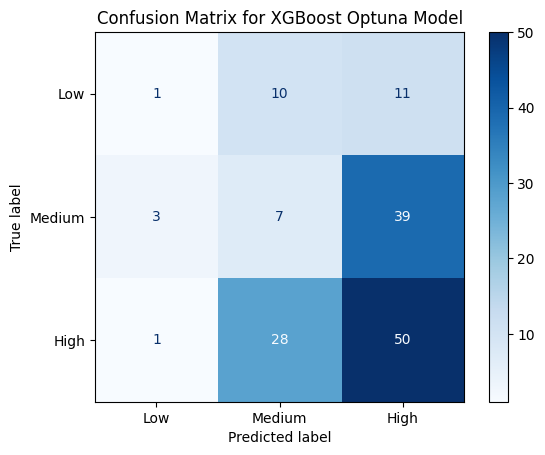

In [78]:
optuna_conf_matrix = confusion_matrix(y_test,optuna_test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=optuna_conf_matrix, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for XGBoost Optuna Model")
plt.show()

In [79]:
results = {
    'Model': ['GaussianNB', 'Logistic Regression', 'SVC', 'Random Forest (Tuned)', 'XGBoost (Baseline)','XGBoost (Optuna)'],
    'Train Accuracy': [
        GNB_model.score(x_train, y_train),
        linear_model.score(x_train, y_train),
        svc_model.score(x_train, y_train),
        grid_rf_model.score(x_train, y_train),
        xgb_model.score(x_train, y_train),
        optuna_model.score(x_train,y_train)
    ],
    'Test Accuracy': [
        GNB_model.score(x_test, y_test),
        linear_model.score(x_test, y_test),
        svc_model.score(x_test, y_test),
        grid_rf_model.score(x_test, y_test),
        xgb_model.score(x_test, y_test),
        optuna_model.score(x_test, y_test)
    ],
    'Test Precision': [
        GNB_test_precision_score,
        linear_test_precision_score,
        svc_test_precision_score,
        grid_rf_test_precision,
        xgb_test_precision,
        optuna_test_precision
    ],
    'Test F1': [
        GNB_f1_score,
        linear_f1_score,
        svc_f1_score,
        grid_rf_f1_score,
        xgb_f1_score,
        optuna_f1_score
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.set_index('Model')
comparison_df = comparison_df.round(4)
comparison_df

,Train Accuracy,Test Accuracy,Test Precision,Test F1
Model,,,,
GaussianNB,0.29,0.29,0.46,0.32
Logistic Regression,0.65,0.51,0.47,0.32
SVC,0.58,0.49,0.35,0.61
Random Forest (Tuned),1.00,0.49,0.62,0.44
XGBoost (Baseline),0.94,0.51,0.47,0.46
XGBoost (Optuna),1.00,0.39,0.34,0.35


In [80]:
final_cols = x_train.columns

In [81]:
feature_importance = pd.Series(xgb_model.feature_importances_, index=final_cols)
feature_importance = feature_importance.sort_values(ascending = False)
print(feature_importance)

Anomaly_Detected           0.10
Project_Type_Dam           0.06
Energy_Consumption         0.04
Labor_Hours                0.04
Material_Usage             0.04
Weather_Condition_Cloudy   0.04
Weather_Condition_Rainy    0.04
Weather_Condition_Snowy    0.04
Equipment_Utilization      0.04
Vibration_Level            0.04
Planned_Duration           0.04
Humidity                   0.04
Load_Bearing_Capacity      0.04
Accident_Count             0.04
Temperature                0.04
Image_Analysis_Score       0.04
Air_Quality_Index          0.04
Crack_Width                0.03
Project_Type_Bridge        0.03
Planned_Cost               0.03
Completion_Percentage      0.03
Project_Type_Tunnel        0.03
Weather_Condition_Sunny    0.03
Project_Type_Building      0.03
Project_Type_Road          0.03
Weather_Condition_Stormy   0.02
dtype: float32


Text(0, 0.5, 'Features')

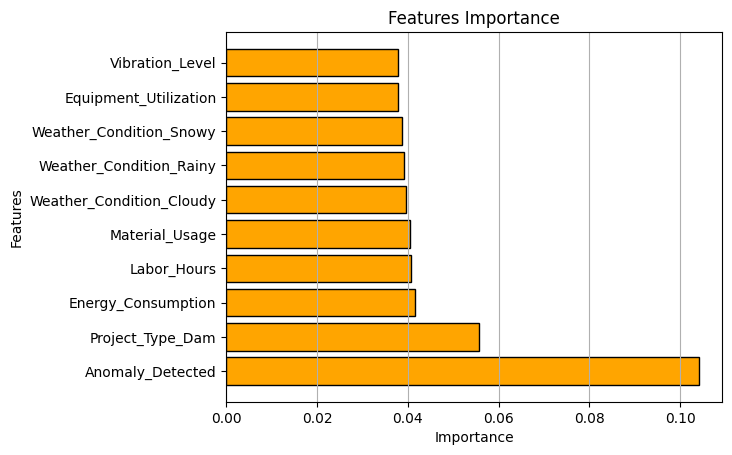

In [82]:
plt.barh(feature_importance.head(10).index,feature_importance.head(10).values,
        edgecolor='black',facecolor='orange')
plt.grid(axis='x')
plt.title("Features Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

In [83]:
import joblib

joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']